In [1]:
import numpy as np
import pandas as pd

import glob
import re
import os
import sys
import warnings

from io import StringIO


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
#def main():

# ignore warnings
warnings.filterwarnings("ignore")

In [3]:
# load recspec file
recspec = pd.read_table('recspec.out',sep='\s+',header=None,
                        names=['energy_midpoint','recoils_ion_ev','energy_width','recoils_ion','unknown','recoils'])

# cut table >= 25 eV <=5000 eV
#recspec = recspec[(recspec['energy_midpoint']>= 25) & (recspec['energy_midpoint']<= 5000)]
#recspec

In [4]:
# load recspec file
file_sim_param = 'simulations_parameters_1-623_npt_aniso.dat'
sim_parm = pd.read_table(file_sim_param,sep=',',header=0)
#sim_parm

# Accumulated DPA

In [5]:
# my system size
my_Natom = 4_609_421

print("Dose = ... dpa")
print(sim_parm['NRT'].sum()/my_Natom)
print(sim_parm['dpa'].sum())

Dose = ... dpa
0.04993333053511112
0.04993333053511111


In [6]:
print_list = sim_parm.groupby(by=['N_sim','E_group'])['N_cube'].count().values
#print(print_list[1000:])

In [7]:
#df_grouped = sim_parm.groupby(by=['N_sim','E_group']).count()
#df_grouped[~df_grouped['N_cube'].isin([245, 18,8,1])]

#file_sim_param = 'simulations_parameters_1-623_npt_aniso.dat'
file_sim_param = 'simulations_parameters_1-623_npt_aniso_for_fig.dat'
sim_parm = pd.read_table(file_sim_param,sep=',',header=0)


df_grouped = sim_parm[sim_parm['N_sim']>0].groupby(by=['N_sim','E_group']).count()
df_grouped[~df_grouped['N_cube'].isin([245, 100, 18, 8])]

df_grouped = sim_parm[sim_parm['N_sim']>28].groupby(by=['N_sim','E_group']).count()
df_grouped[~df_grouped['N_cube'].isin([294, 100, 18, 8])]

df_grouped = sim_parm[sim_parm['N_sim']>79].groupby(by=['N_sim','E_group']).count()
df_grouped[~df_grouped['N_cube'].isin([294, 100,27,8])]

df_grouped = sim_parm[sim_parm['N_sim']>94].groupby(by=['N_sim','E_group']).count()
df_grouped[~df_grouped['N_cube'].isin([252, 125,27,8])]

df_grouped = sim_parm[sim_parm['N_sim']>347].groupby(by=['N_sim','E_group']).count()
#df_grouped[~df_grouped['N_cube'].isin([216, 125,27,8])]

In [8]:
category_of_pka_energy = []
for energy in recspec['energy_midpoint']:
    category_of_pka_energy.append([recspec[recspec['energy_midpoint']==energy]['energy_midpoint'].values[0] - recspec[recspec['energy_midpoint']==energy]['energy_width'].values[0]/2,
                                   recspec[recspec['energy_midpoint']==energy]['energy_midpoint'].values[0] + recspec[recspec['energy_midpoint']==energy]['energy_width'].values[0]/2,
                                   recspec[recspec['energy_midpoint']==energy]['energy_midpoint'].values[0]
                                  ])

#category_of_pka_energy

In [9]:
# assign energy to some group 
def energy_category(energy):
    for i in category_of_pka_energy:
            #print(i);
        cond=(i[0]< energy and energy <= i[1]);
        if cond: 
            return i[2]
        else:
            pass
    #raise ValueError
    print("Error: Incorrect value of energy")

sim_parm['energy_midpoint'] = sim_parm['E_pka'].apply(energy_category)
#sim_parm

In [10]:
sim_spec = sim_parm.groupby('energy_midpoint')['N_cube'].count()
sim_spec.reset_index()
sim_spec.reset_index()
sim_spec.reset_index()

sim_spec = pd.merge(recspec[['energy_midpoint','energy_width']],sim_spec, how="outer", on=["energy_midpoint"])
sim_spec['recoils_ion_ev'] = sim_spec['N_cube']/sim_spec['energy_width']
#sim_spec

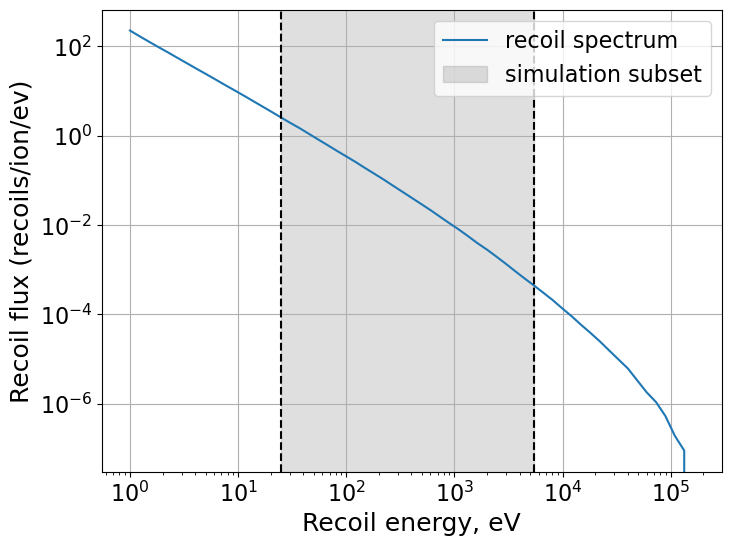

In [24]:
#fig_size=(10, 6)
fig_size=(8, 6)
fontsize = 18
fig = plt.figure(figsize=fig_size)

#plt.step(recspec['energy_midpoint'],recspec['recoils_ion_ev'],where='mid',label='experiment')
#plt.step(sim_spec['energy_midpoint'],sim_spec['recoils_ion_ev']/600,where='mid',label='simulations')
plt.plot(recspec['energy_midpoint'],recspec['recoils_ion_ev'],label='recoil spectrum')
#plt.plot(sim_spec['energy_midpoint'],sim_spec['recoils_ion_ev']/600,label='simulation subset')

plt.axvline(x=25, ymin=0.00001, ymax=1,color='black',linestyle='--')
plt.axvline(x=5500, ymin=0.00001, ymax=1,color='black',linestyle='--')
plt.axvspan(25,5500, alpha=0.25, color='grey',label='simulation subset')


plt.grid()
plt.xlabel('Recoil energy, eV', fontsize=fontsize)
plt.ylabel('Recoil flux (recoils/ion/ev)', fontsize=fontsize)

plt.xscale('log')
plt.yscale('log')

plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)

plt.legend(fontsize=fontsize-2)

#plt.ylim(0,1)

plt.savefig('fig_recoil_spectrum.png')

# Accumulated DPA (for TDE = 60 eV)

In [12]:
# Values TDE, Z, A for carbon
Z = 6
A = 12.011
TDE = 28

# my system size
my_Natom = 4_609_421

In [13]:
#calculating damage energy
def Tdam_calc(kinetic_energy,charge_number,atomic_number):
    kinetic_energy = kinetic_energy / 1000 # all should be in keV
    
    # paremeters
    k = 0.1337 * (charge_number**(2/3)) / (atomic_number**(1/2))
    epsilon = kinetic_energy / 0.08693 / (charge_number**(7/3))
    g = epsilon + 0.40244*(epsilon**(3/4)) + 3.4008*(epsilon**(1/6))
    
    damage_energy = kinetic_energy/(1 + k*g)
    damage_energy = damage_energy * 1000 # return to eV
    return damage_energy

In [14]:
#calculating Nnrt depending on damage energy
def NRT_calc(damage_energy,threshold_energy):
    if damage_energy <= threshold_energy:
        nrt_defects = 0
    elif damage_energy <= 2*threshold_energy/0.8:
        nrt_defects = 1
    else:
        nrt_defects = 0.8*damage_energy/(2*threshold_energy)
    
    return nrt_defects

In [15]:
# load file
file_sim_param
sim_parm = pd.read_table(file_sim_param,sep=',',header=0)

# calculating Nnrt cause by recoil of certain energy
sim_parm['Tdam'] = sim_parm['E_pka'].apply(lambda x: Tdam_calc(x,Z,A)
                                          )

sim_parm['new_NRT'] = sim_parm['Tdam'].apply(lambda x: NRT_calc(x,TDE)
                                          )
sim_parm['new_dpa'] = sim_parm['new_NRT']/my_Natom
    
#sim_parm[['NRT','dpa','new_NRT','new_dpa']]

# Recalculated accumulated DPA

In [16]:
print("Dose = ... dpa (TDE = 25 eV)")
print(sim_parm['NRT'].sum()/my_Natom)
print(sim_parm['dpa'].sum())

print("Dose = ... dpa (TDE =", TDE, "eV)")
print(sim_parm['new_NRT'].sum()/my_Natom)
print(sim_parm['new_dpa'].sum())

Dose = ... dpa (TDE = 25 eV)
0.05505319060802227
0.055053190608022266
Dose = ... dpa (TDE = 28 eV)
0.04896076911477579
0.048960769114775794


# Recalculated accumulated DPA up to sim = x

In [17]:
sim = 550

#print("Dose = ... dpa (TDE = 25 eV)")
#print(sim_parm[sim_parm['N_sim'] <= sim]['NRT'].sum()/my_Natom)
#print(sim_parm[sim_parm['N_sim'] <= sim]['dpa'].sum())

print("Dose = ... dpa (TDE =", TDE, "eV)")
print(sim_parm[sim_parm['N_sim'] <= sim]['new_NRT'].sum()/my_Natom)
print(sim_parm[sim_parm['N_sim'] <= sim]['new_dpa'].sum())

Dose = ... dpa (TDE = 28 eV)
0.04183173958473102
0.04183173958473102
